In [5]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
sys.path.append('/home/jiaxuanl/Research/Packages/romanisim/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import asdf
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table, vstack, Column, hstack
from astropy import units as u
from astropy.visualization import simple_norm
import copy
import galsim
import roman_datamodels as rdm
from romanisim import gaia, bandpass, catalog, log, wcs, persistence, parameters, ris_make_utils as ris
from romanisim.image import inject_sources_into_l2
from romanisim.l3 import inject_sources_into_l3

Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [45]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = "30"
import artpop
import rosesim
from rosesim.display import show_image_wcs
from rosesim.rose import RomanGalaxy, RomanSky, RomanSymphony
rng = np.random.RandomState(100)
DATA_PATH = rosesim.DATA_PATH
SYMPHONY_PATH = '/scratch/gpfs/JENNYG/jiaxuanl/Data/Roman/symphony/'

In [11]:
from astropy.table import Table, vstack, hstack
import h5py
import pandas as pd
from tqdm import trange

def read_h5_to_dict(filename):
    """Reads an HDF5 file and returns a dictionary with all datasets."""
    data = {}

    def recursively_load(h5obj, prefix=''):
        for key in h5obj:
            item = h5obj[key]
            path = f"{prefix}/{key}" if prefix else key
            if isinstance(item, h5py.Dataset):
                data[path] = item[()]
            elif isinstance(item, h5py.Group):
                recursively_load(item, path)

    with h5py.File(filename, 'r') as f:
        recursively_load(f)

    return data

def read_h5_into_df(f, vega_to_ab=True, abs_F158_lim=4):
    """Read HDF5 file into pandas DataFrame."""
    df = pd.DataFrame()
    try:
        dt = read_h5_to_dict(f)
        for key in dt.keys():
            if key != 'mags':  # Skip 2D mags array, extract separately
                df[key] = dt[key]
        # Extract magnitudes from 2D array
        mags = dt['mags']
        mag_names = ['F062mag', 'F087mag', 'F106mag', 'F129mag', 
                     'F158mag', 'F184mag', 'F146mag', 'F213mag']
        if vega_to_ab:
            for i, name in enumerate(mag_names):
                df['abs_' + name] = mags[:, i] + rosesim.Roman_zp_AB_Vega_parsec[name.replace('mag', '')] 
                # Prefix with 'abs_' to indicate absolute magnitudes
        else:
            for i, name in enumerate(mag_names):
                df['abs_' + name] = mags[:, i] # Prefix with 'abs_' to indicate absolute magnitudes

        df = df[df['abs_F158mag'] < abs_F158_lim]
    except Exception as e:
        print(f"Could not read file {f}: {e}")
    return df

## We already have a sky object. Let's just load the symphony mocks, put it at 8 Mpc, and see how that look like

In [357]:
gal = RomanSymphony(prefix='symphony_test', data_dir=DATA_PATH)

In [441]:
# we use empty sky for now
obs_ra = 150.1049
obs_dec = 2.2741
# obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253

gal_kwargs = {'distance': 4 * u.Mpc}

dist = gal_kwargs['distance'].to(u.Mpc).value
dmod = 5 * np.log10(dist) + 25

abs_mag_lim = 4
mag_lim = dmod + abs_mag_lim
print('mag lim', mag_lim)

mag lim 32.01029995663981


In [442]:
gal.kwargs = gal_kwargs

In [443]:
filt = 'F106'
t_exp = 642
gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky/{filt}_{t_exp}s.asdf')
# gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf')
gal.roman_wcs = gal.sky_dm.meta.wcs

Loaded background from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky/F106_642s.asdf


In [444]:
import glob
files = glob.glob(SYMPHONY_PATH + 'symphony_halo023_pid*_roman.h5')

In [445]:
# files = ['symphony_halo023_pid24_roman.h5'] # this is the accreted mass from a subhalo PID-24
# files = ['gc_streams_halo023.h5']
files = [os.path.join(SYMPHONY_PATH, file) for file in files]
df = pd.concat([read_h5_into_df(f, vega_to_ab=True, abs_F158_lim=abs_mag_lim) for f in files], ignore_index=True)
# src = Table.from_df(df)

In [447]:
df.to_csv(SYMPHONY_PATH + '/symphony_halo023_all_F158_-4.csv')

In [435]:
delta_x = np.rad2deg(src['x'] / (dist * 1e3))
delta_y = np.rad2deg(src['y'] / (dist * 1e3))
delta_x -= np.median(delta_x)
delta_y -= np.median(delta_y)
delta_ra = delta_x / np.cos(np.deg2rad(obs_dec))
delta_dec = delta_y

src['ra'], src['dec'] = obs_ra + delta_ra, obs_dec + delta_dec
flag = gal.roman_wcs.in_image(SkyCoord(src['ra'], src['dec'], unit='deg'))
gal.load_src(src[flag], ra=obs_ra, dec=obs_dec)

mag_table = gal.src.copy()
for filt in gal.filters:
    mag_table[filt] = mag_table[f'abs_{filt}mag'] + dmod
for filt in gal.filters:
    mag_table[filt] = 10**(-0.4 * mag_table[filt]) # to maggies

pts_table = Table()
pts_table['type'] = Column(data=['PSF']*len(mag_table))
pts_table = hstack([pts_table, mag_table])
full_table = pts_table
flag = (full_table['abs_F106mag'] - full_table['abs_F158mag']) > 0.75
full_table = full_table[flag]
full_table.write(f'./temp/full_table.ecsv', format='ascii.ecsv', overwrite=True)
gal.obj_cat = full_table
print('Catalogue generated.')

Catalogue generated.


(-1.0, 1.5)

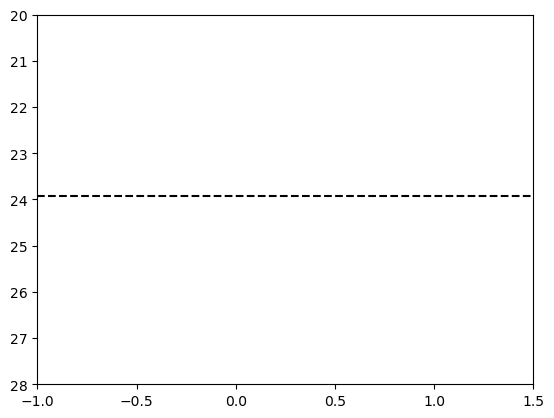

In [436]:
plt.scatter(gal.obj_cat['abs_F106mag'] - gal.obj_cat['abs_F158mag'], gal.obj_cat['abs_F106mag'] + dmod, s=1)

plt.axhline(-5.4 + dmod + rosesim.Roman_zp_AB_Vega_parsec['F158'], ls='--', c='k')
plt.ylim(28, 20)
plt.xlim(-1, 1.5)

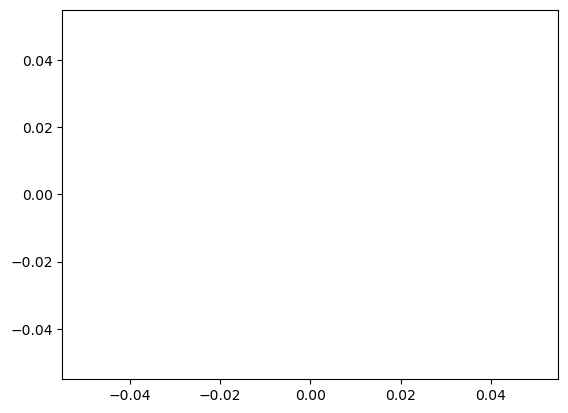

In [437]:
plt.scatter(gal.obj_cat['ra'], gal.obj_cat['dec'], s=1)

In [438]:
len(gal.obj_cat)

0

In [420]:
# pts_table.write(f'./temp/pts_table.ecsv', format='ascii.ecsv', overwrite=True)

In [421]:
for filt in ['F106', 'F129', 'F158']:
    # gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf')
    gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky/{filt}_{t_exp}s.asdf')
    gal.observe(exptimes=t_exp, psftype='epsf', fastpointsources=True)
    gal.dm.save(f'./{filt}_{t_exp}s_epsf_fast.asdf')

Loaded background from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky/F106_642s.asdf


2026-01-26 21:39:53 INFO     Setting pixscale to match default.


2026-01-26 21:39:53 WARNING  wcs is None; unlikely to get orientation of PSF correct.


2026-01-26 21:39:53 INFO     Creating PSF from CRDS reference type epsf


2026-01-26 21:39:53 WARNING  wcs is None; unlikely to get orientation of PSF correct.


...

2026-01-26 21:40:26 INFO     Creating PSF from CRDS reference type epsf


2026-01-26 21:40:26 INFO     Adding 52890 sources to image...


2026-01-26 21:40:37 INFO     Rendered 52890 point sources in 4.42 seconds


2026-01-26 21:40:37 INFO     Rendered 52890 total sources in 4.45 seconds


2026-01-26 21:40:37 INFO     Total counts: 0


In [121]:
from galsim import roman
import warnings
from copy import deepcopy
import astrocut
from astrocut import get_center_pixel, ASDFCutout
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

In [184]:
asdf_cutout = ASDFCutout("./F106_642s_galsim_fast.asdf", 
                         SkyCoord(obs_ra, obs_dec, unit='deg'), 
                         1200)
img_galsim_fast = asdf_cutout.cutouts[0].data - 0.314

asdf_cutout = ASDFCutout("./F106_642s_galsim_slow.asdf", 
                         SkyCoord(obs_ra, obs_dec, unit='deg'), 
                         1200)
img_galsim_slow = asdf_cutout.cutouts[0].data - 0.314

In [13]:
# dm = rosesim.utils.read_L3_asdf('./F158_642s.asdf')
# psf = dm.psf

In [45]:
dm = rosesim.read_L3_asdf('./F106_642s.asdf')

In [193]:
rosesim.utils.asdf_to_fits(dm, './test.fits', subtract_bkg=True)

Successfully wrote FITS file: ./test.fits


In [162]:
rosesim.asdf_to_fits(gal.dm, f'{filt}_642s.fits', subtract_bkg=True)

Successfully wrote FITS file: F158_642s.fits


# Visualize

In [202]:
# cen_ra, cen_dec = 11.8880580, -25.2888000 

In [205]:
SkyCoord(obs_ra, obs_dec, unit='deg')

<SkyCoord (ICRS): (ra, dec) in deg
    (150.1049, 2.2741)>

In [422]:
from astropy.visualization import make_lupton_rgb
import sep

zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


In [423]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/symphony_test'

In [424]:
prefix = 'ufd_1e6_25Mpc_1.0Gyr'
# prefix = 'dw_1e5.5_20Mpc_1.0Gyr'
prefix = 'dw_1e7.0_35Mpc_0.4Gyr'
# prefix = 'ufd_1e3_2Mpc_0.4Gyr'
# prefix = 'dw_1e5.5_2Mpc_2.0Gyr'
prefix = 'dw_1e5.5_2Mpc_age9.6_feh-1.5'
# prefix = 'dw_1e6.0_2Mpc_age9.6_feh-1.5'
# prefix = 'dw_1e4.5_3.0Mpc_age9.6_feh-2.0'
# prefix = 'dw_1e6.0_10.0Mpc_age9.6_feh-2.0'
# prefix = 'dw_1e6.0_2.0Mpc_age9.6_feh-2.0'
prefix = 'dw_1e5.5_2.0Mpc_age9.6_feh-1.5'
prefix = 'symphony_test'

In [425]:
# obs_ra, obs_dec = 150.0763360, 2.3118682

In [426]:
cen_ra, cen_dec = obs_ra, obs_dec
import sep

In [427]:
filters = ['F106', 'F129', 'F158']
imgs = []
# t_exp = 10272
t_exp = 642
for filt in filters:
    file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_{t_exp}s_epsf_fast.asdf", 
    # file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf", 
    # file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal/{filt}_642s.asdf", 
    asdf_cutout = ASDFCutout(file,
                             SkyCoord(cen_ra, cen_dec, unit='deg'), 5001) # 5001
    # SkyCoord(obs_ra, obs_dec, unit='deg'), 4069) # 5001
    
    hdu = asdf_cutout.fits_cutouts[0]
    img = hdu[0].data
    bkg = sep.Background(img, bw=256, bh=256)
    hdu[0].data -= bkg.globalback
    hdu.writeto(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_642s_cutout.fits', overwrite=True)

    img *= 10**(0.4 * (27 - zp))
    # imgs.append(img[250:1250, :])
    imgs.append(img[:, :])

In [428]:
import rosesim

In [429]:
# rgb = make_lupton_rgb(0.95 * imgs[2], 1.15 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=0.2, Q=3)
rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=0.5, Q=1)
# fig, ax = plt.subplots(figsize=(10, 10))
fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb) #, origin='lower')
plt.axis('off')

# plt.text(wid - 0.2 * wid, +5, filters[filt_idx[0]], 
         # fontsize=20, color='deepskyblue', va='center', ha='center')
# plt.text(wid, +5, filters[filt_idx[1]], 
         # fontsize=20, color='limegreen', va='center', ha='center')
# plt.text(wid + 0.2 * wid, +5, filters[filt_idx[2]], 
         # fontsize=20, color='orangered', va='center', ha='center')
# title = prefix
# plt.title(title, fontsize=20)

plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png', bbox_inches='tight', dpi=200, transparent=True, pad_inches=0)
plt.close()

(np.float64(-0.5), np.float64(299.5), np.float64(299.5), np.float64(-0.5))

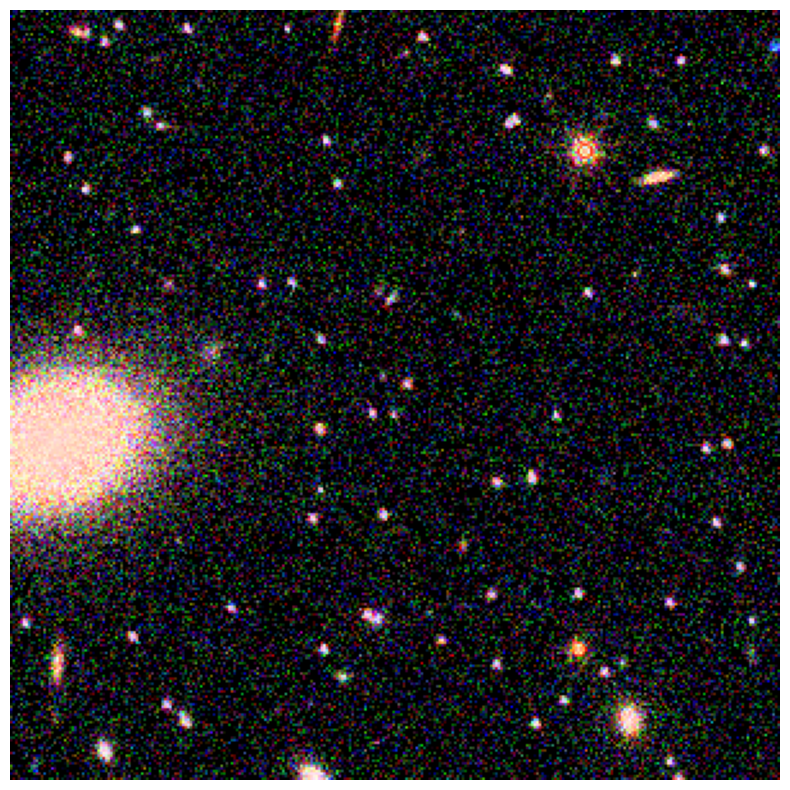

In [370]:
# rgb = make_lupton_rgb(0.95 * imgs[2], 1.15 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=0.2, Q=3)
rgb = make_lupton_rgb(1 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=0.5, Q=1)
fig, ax = plt.subplots(figsize=(10, 10))
# fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb[:300, :300]) #, origin='lower')
plt.axis('off')

# plt.text(wid - 0.2 * wid, +5, filters[filt_idx[0]], 
         # fontsize=20, color='deepskyblue', va='center', ha='center')
# plt.text(wid, +5, filters[filt_idx[1]], 
         # fontsize=20, color='limegreen', va='center', ha='center')
# plt.text(wid + 0.2 * wid, +5, filters[filt_idx[2]], 
         # fontsize=20, color='orangered', va='center', ha='center')
# title = prefix
# plt.title(title, fontsize=20)

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png', bbox_inches='tight', dpi=200, transparent=True, pad_inches=0)
# plt.close()

----

## Image gallery

In [275]:
for mass in [5.5, 6, 6.5, 7]:
    for dist in [50]:
        prefix = f'dw_1e{mass:.1f}_{int(dist)}Mpc_1.0Gyr'
    
        filters = ['F106', 'F129', 'F158']
        imgs = []
        for filt in filters:
            asdf_cutout = ASDFCutout(f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_642s.asdf", 
                                     SkyCoord(obs_ra, obs_dec, unit='deg'), 300)
        
            hdu = asdf_cutout.fits_cutouts[0]
            hdu.writeto(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_642s_cutout.fits', overwrite=True)
        
            img = asdf_cutout.cutouts[0].data
            img -= np.median(img)
            img *= 10**(0.4 * (27 - zp))
            imgs.append(img[:, :])
    
        rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=1, Q=3)
        fig, ax = plt.subplots(figsize=(10, 10))
        plt.imshow(rgb)
        plt.axis('off')
        plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png', bbox_inches='tight', dpi=200, transparent=True)
        plt.close()

In [ ]:
from PIL import Image

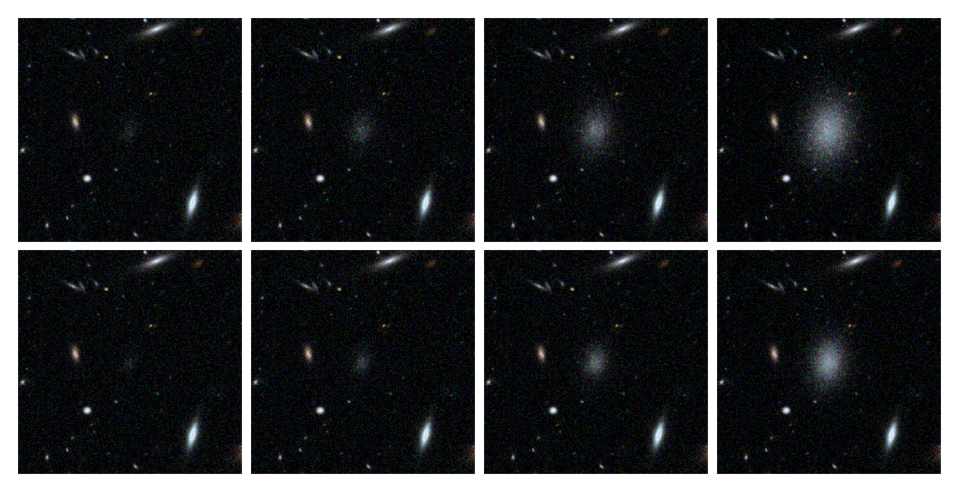

In [280]:
fig, axes = plt.subplots(2, 4, figsize=(4*2, 2*2), dpi=150)
# for ax in axes.flatten():
    # ax.axis('off')
for i, mass in enumerate([5.5, 6, 6.5, 7]):
    for j, dist in enumerate([35, 50]):
        prefix = f'dw_1e{mass:.1f}_{int(dist)}Mpc_1.0Gyr'
        file = f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png'

        ax = axes[j, i]
        image = Image.open(file)
        ax.imshow(image, origin='upper')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        # ax.text(0.05, 0.05, f'{obj['name']}', transform=ax.transAxes, ha='left', color='gray', fontsize=10)
        # ax.text(0.95, 0.85, f'{obj['stage']}', transform=ax.transAxes, ha='right', color='w', fontsize=12)
        # ax.text(0.95, 0.05, f'z={obj['z']:.4f}', transform=ax.transAxes, ha='right', color='w', fontsize=10)

plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/summary.png', bbox_inches='tight', transparent=True, dpi=200)

In [ ]:
26.5 mag in 1 pix

In [87]:
sigma = 10**(-0.4 * 26.5) / 5
sigma

5.023772863019144e-12

In [86]:
-2.5 * np.log10(sigma / np.sqrt(100 * 100))

33.24742501084005

In [88]:
10**(-0.4 * 30.5)

6.309573444801917e-13

In [90]:
sigma / 6.309573444801917e-13

7.962143411069938

---

In [13]:
import numpy as np

def flux_to_mag(flux):
    """AB-like: m = -2.5 log10(flux). Assumes flux>0."""
    flux = np.asarray(flux)
    m = np.full_like(flux, np.nan, dtype=float)
    good = flux > 0
    m[good] = -2.5 * np.log10(flux[good])
    return m

def mag_to_flux(mag):
    """Inverse of m = -2.5 log10(flux)."""
    mag = np.asarray(mag)
    return 10**(-0.4 * mag)

def apply_obs_model_two_band(
    flux_F106,
    flux_F158,
    completeness_dict,
    mag_uncertainty_dict,
    depth_HLWAS=1,
    rng=None,
    detection="both",
    ref_band="F158",
    return_flux=True,
    clip_sigma=None,
):
    """
    Forward-model incompleteness + photometric scatter for two-band photometry.

    Parameters
    ----------
    flux_F106, flux_F158 : array-like
        "True" fluxes (must be >0 to yield finite magnitudes).
    completeness_dict : dict
        e.g. {'F106': [m50, w], 'F158': [m50, w]}
    mag_uncertainty_dict : dict
        e.g. {'F106': [slope, intercept], 'F158': [slope, intercept]}
    rng : np.random.Generator, optional
        If None, uses default_rng().
    detection : {"both","either","ref"}
        - "both": require detection in both bands (common for colors).
        - "either": detected if either band is detected.
        - "ref": detected if detected in ref_band only (common for detection image).
    ref_band : {"F106","F158"}
        Used only if detection="ref".
    return_flux : bool
        If True, also return noisy fluxes computed from noisy magnitudes.
    clip_sigma : float or None
        If set, clip magnitude perturbations to +/- clip_sigma * sigma_m (rarely needed).

    Returns
    -------
    out : dict
        Keys include:
          - 'detected' (bool mask)
          - 'm_true_F106', 'm_true_F158'
          - 'm_obs_F106', 'm_obs_F158' (NaN if not detected)
          - optionally 'flux_obs_F106', 'flux_obs_F158'
          - 'sigma_m_F106', 'sigma_m_F158' (evaluated at m_true)
          - 'pdet_F106', 'pdet_F158'
    """
    if rng is None:
        rng = np.random.default_rng()

    flux_F106 = np.asarray(flux_F106, dtype=float)
    flux_F158 = np.asarray(flux_F158, dtype=float)

    # True magnitudes
    m_true_F106 = flux_to_mag(flux_F106)
    m_true_F158 = flux_to_mag(flux_F158)

    delta_mag = 1.25 * np.log10(depth_HLWAS)
    # Detection probabilities from completeness curves (evaluated at true mags)
    pdet_F106 = logistic_completeness(m_true_F106 - delta_mag, *completeness_dict["F106"])
    pdet_F158 = logistic_completeness(m_true_F158 - delta_mag, *completeness_dict["F158"])

    # Realize detections (Bernoulli trials)
    det_F106 = rng.random(size=m_true_F106.size) < pdet_F106
    det_F158 = rng.random(size=m_true_F158.size) < pdet_F158

    if detection == "both":
        detected = det_F106 & det_F158
    elif detection == "either":
        detected = det_F106 | det_F158
    elif detection == "ref":
        if ref_band == "F106":
            detected = det_F106
        elif ref_band == "F158":
            detected = det_F158
        else:
            raise ValueError("ref_band must be 'F106' or 'F158'")
    else:
        raise ValueError("detection must be one of {'both','either','ref'}")

    # Photometric uncertainty model (evaluated at true mags)
    sigma_m_F106 = mag_uncertainty_func(m_true_F106 - delta_mag, *mag_uncertainty_dict["F106"])
    sigma_m_F158 = mag_uncertainty_func(m_true_F158 - delta_mag, *mag_uncertainty_dict["F158"])

    # Initialize observed mags as NaN (non-detections remain missing)
    m_obs_F106 = np.full_like(m_true_F106, np.nan, dtype=float)
    m_obs_F158 = np.full_like(m_true_F158, np.nan, dtype=float)

    # Draw perturbations for detected objects only
    idx = np.where(detected)[0]
    if idx.size > 0:
        dm106 = rng.normal(loc=0.0, scale=sigma_m_F106[idx])
        dm158 = rng.normal(loc=0.0, scale=sigma_m_F158[idx])

        if clip_sigma is not None:
            dm106 = np.clip(dm106, -clip_sigma * sigma_m_F106[idx], clip_sigma * sigma_m_F106[idx])
            dm158 = np.clip(dm158, -clip_sigma * sigma_m_F158[idx], clip_sigma * sigma_m_F158[idx])

        m_obs_F106[idx] = m_true_F106[idx] + dm106
        m_obs_F158[idx] = m_true_F158[idx] + dm158

    out = dict(
        detected=detected,
        m_true_F106=m_true_F106,
        m_true_F158=m_true_F158,
        m_obs_F106=m_obs_F106,
        m_obs_F158=m_obs_F158,
        sigma_m_F106=sigma_m_F106,
        sigma_m_F158=sigma_m_F158,
        pdet_F106=pdet_F106,
        pdet_F158=pdet_F158,
    )
    return out


In [14]:
cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253_sizecut/temp/sky_table.ecsv')
cat = cat[cat['half_light_radius'] < 0.15]
# flag = flux_to_mag(cat['F158']) < 27
# cat = cat[flag]

# Dwarf “member” stars (your red points)
m158_g = flux_to_mag(gal.obj_cat['F158'])
c_g    = flux_to_mag(gal.obj_cat['F106']) - flux_to_mag(gal.obj_cat['F158'])  # (F106 - F158)

# Background sources (your black points; SER subset)
m158_b = flux_to_mag(cat['F158'])
c_b    = flux_to_mag(cat['F106'] / cat['F158'])  # equivalent to mag(F106)-mag(F158)

Text(0, 0.5, 'Dec')

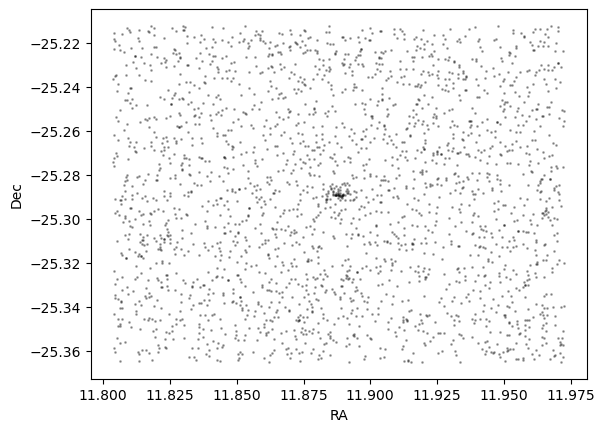

In [20]:
# plt.scatter(cat['ra'], cat['dec'], s=1, c='k', alpha=0.3)
plt.scatter(cat['ra'][inside], cat['dec'][inside], s=1, c='k', alpha=0.3)

flag = -2.5 * np.log10(gal.obj_cat['F158']) < 27
plt.scatter(gal.obj_cat['ra'][flag], gal.obj_cat['dec'][flag], s=1, c='k', alpha=0.3)

plt.xlabel('RA')
plt.ylabel('Dec')

In [18]:
from scipy.spatial import cKDTree

dmag = 0.1
dcol = 0.2

# Rescale axes so that "1 unit" corresponds to your tolerance in each axis.
X_g = np.column_stack([c_g / dcol,  m158_g / dmag])
X_b = np.column_stack([c_b / dcol,  m158_b / dmag])

tree = cKDTree(X_g)
dist, _ = tree.query(X_b, k=1)

# dist < 1 means within an ellipse: (Δcolor/dcol)^2 + (Δmag/dmag)^2 < 1
inside = dist < 0.6

sel_m158_b = m158_b[inside]
sel_c_b    = c_b[inside]

Text(0, 0.5, 'F158')

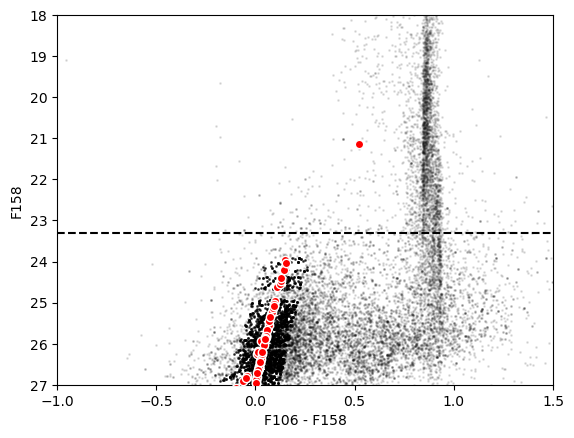

Text(0, 0.5, 'F158')

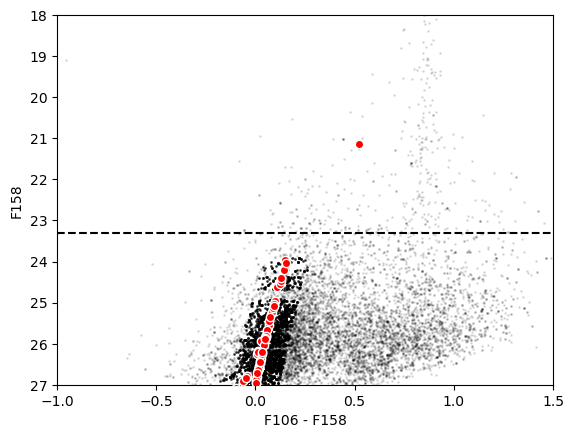

In [19]:
plt.scatter(c_g, m158_g, color='r', zorder=10, ec='w')

plt.scatter(c_b, m158_b, c='k', alpha=0.1, s=1)
plt.scatter(sel_c_b, sel_m158_b, c='k', alpha=0.6, s=1)

plt.axhline(-5.4 + sp.dist_mod + rosesim.Roman_zp_AB_Vega_parsec['F158'], ls='--', c='k')

plt.ylim(27, 18)
plt.xlim(-1, 1.5)

plt.xlabel('F106 - F158')
plt.ylabel('F158')

In [21]:
def logistic_completeness(m, m50, w):
    return 1.0 / (1.0 + np.exp((m - m50) / w))

def mag_uncertainty_func(m, slope, intercept):
    return 10**(m * slope + intercept)

completeness_dict = {'F158': [26.265128309473074, 0.20950393512684282], 
                     'F106': [26.65420231875137, 0.24173024529576023]} # HLWAS depth
mag_uncertainty_dict = {'F158': [0.37152117, -10.49171066], 
                        'F106': [0.38426587, -10.92600549]} # HLWAS depth

In [22]:
rng = np.random.default_rng(123)
depth_HLWAS = 8

# Ultra-faint dwarf sources
ufd = apply_obs_model_two_band(
    gal.obj_cat["F106"], gal.obj_cat["F158"],
    completeness_dict=completeness_dict,
    mag_uncertainty_dict=mag_uncertainty_dict,
    rng=rng,
    detection="both",     # since you care about colors
    return_flux=True,
    depth_HLWAS=depth_HLWAS
)

# Background sources (same forward model)
bkg = apply_obs_model_two_band(
    cat["F106"], cat["F158"],
    completeness_dict=completeness_dict,
    mag_uncertainty_dict=mag_uncertainty_dict,
    rng=rng,
    detection="both",
    return_flux=True,
    depth_HLWAS=depth_HLWAS
)

In [23]:
# Ultra-faint dwarf
mask_ufd = np.isfinite(ufd["m_obs_F106"]) & np.isfinite(ufd["m_obs_F158"])
c_ufd = ufd["m_obs_F106"][mask_ufd] - ufd["m_obs_F158"][mask_ufd]
m_ufd = ufd["m_obs_F158"][mask_ufd]

# Background
mask_bkg = np.isfinite(bkg["m_obs_F106"]) & np.isfinite(bkg["m_obs_F158"])
c_bkg = bkg["m_obs_F106"][mask_bkg] - bkg["m_obs_F158"][mask_bkg]
m_bkg = bkg["m_obs_F158"][mask_bkg]


In [24]:
from scipy.spatial import cKDTree

dmag = 0.2
dcol = 0.3

# Rescale axes so that "1 unit" corresponds to your tolerance in each axis.
X_g = np.column_stack([c_g / dcol,  m158_g / dmag])
X_b = np.column_stack([c_bkg / dcol,  m_bkg / dmag])

tree = cKDTree(X_g)
dist, _ = tree.query(X_b, k=1)

# dist < 1 means within an ellipse: (Δcolor/dcol)^2 + (Δmag/dmag)^2 < 1
inside = dist < 1

Text(0, 0.5, 'Dec')

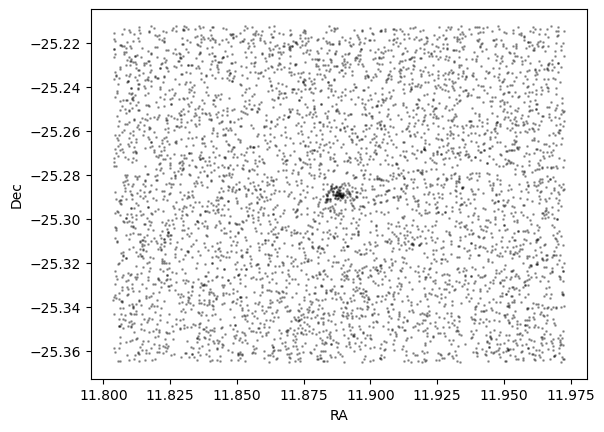

In [31]:
plt.scatter(cat[mask_bkg][inside]['ra'], cat[mask_bkg][inside]['dec'], s=1, c='k', alpha=0.3)

plt.scatter(gal.obj_cat['ra'][mask_ufd], gal.obj_cat['dec'][mask_ufd], s=1, c='k', alpha=0.3)

plt.xlabel('RA')
plt.ylabel('Dec')

In [38]:
np.logspace(np.log10(1 / 3600), np.log10(180 / 3600), 10)

array([0.00027778, 0.00049463, 0.00088078, 0.00156839, 0.00279281,
       0.00497309, 0.00885549, 0.01576879, 0.02807916, 0.05      ])

In [ ]:
np.arange(0.001, 0.3, 0.001)

Text(0, 0.5, 'F158')

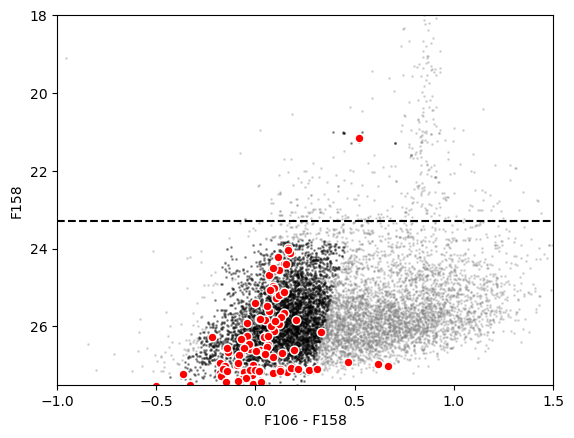

In [32]:
fig, ax = plt.subplots()
plt.axhline(-5.4 + sp.dist_mod + rosesim.Roman_zp_AB_Vega_parsec['F158'], ls='--', c='k')

plt.scatter(c_bkg, m_bkg, s=1, c="gray", alpha=0.25)
plt.scatter(c_bkg[inside], m_bkg[inside], s=1, c="k", alpha=0.25)
plt.scatter(c_ufd, m_ufd, s=40, c="r", alpha=1, ec='w')

plt.ylim(27.5, 18)
plt.xlim(-1, 1.5)
plt.xlabel("F106 - F158")
plt.ylabel("F158")